            count
label            
romance      7558
fantasy      7126
history      2880
thriller     1479
crime        1073
psychology    931
science       834
horror        827
travel        401
sports        260


<Axes: xlabel='label', ylabel='count'>

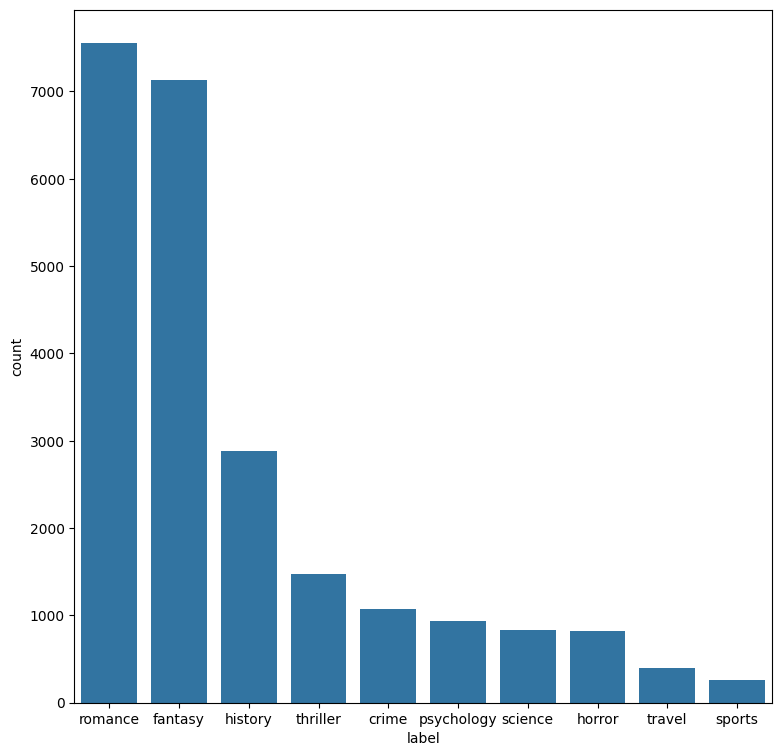

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud

data = pd.read_csv("reduced.csv")


statistics = pd.DataFrame(data['label'].value_counts())
print(statistics)

plt.figure(figsize=(9,9))
sns.barplot(statistics, x="label", y="count")

In [2]:
# Frequent words count, quick analysis

all_words = data['text'].str.split().explode()

word_counts = all_words.value_counts()
frequent_words_10 = set(word_counts[word_counts > 10].index)
frequent_words_20 = set(word_counts[word_counts > 20].index)
frequent_words_30 = set(word_counts[word_counts > 30].index)

print("Words appearing more than once count: ", len(set(word_counts.index)))
print("Words appearing more than 10 times count: ", len(frequent_words_10))
print("Words appearing more than 20 times count: ", len(frequent_words_20))
print("Words appearing more than 30 times count: ", len(frequent_words_30))

Words appearing more than once count:  41987
Words appearing more than 10 times count:  12745
Words appearing more than 20 times count:  8564
Words appearing more than 30 times count:  6716


history


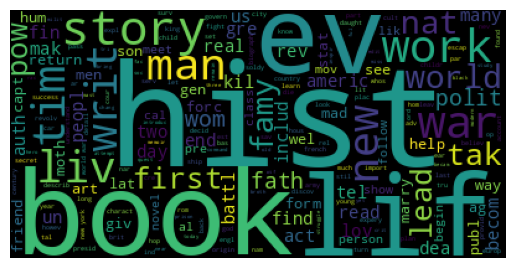

thriller


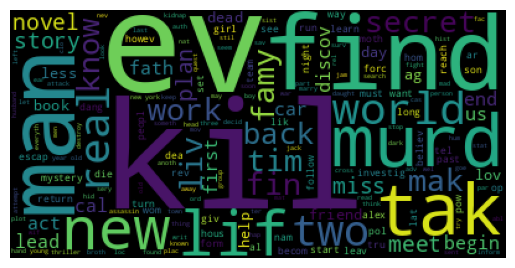

romance


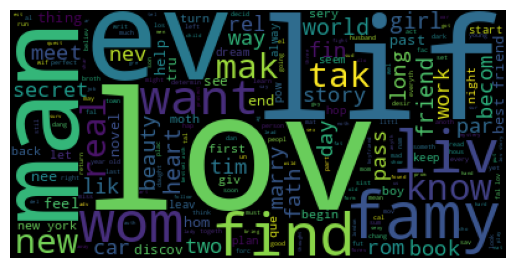

fantasy


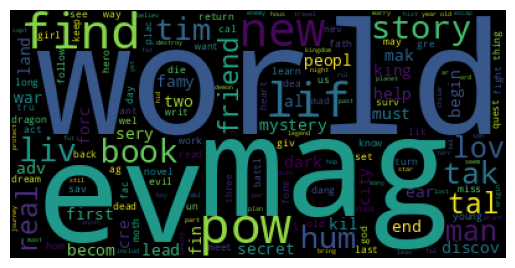

crime


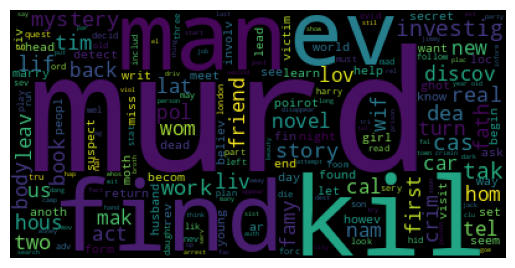

science


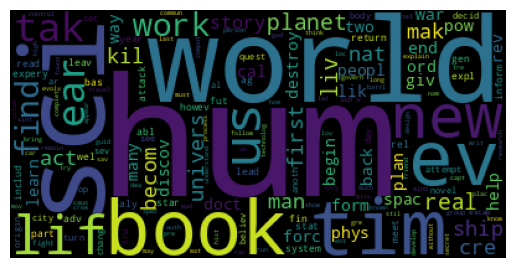

psychology


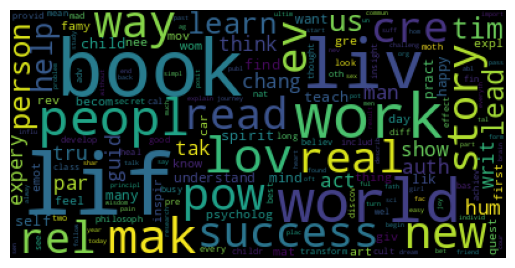

travel


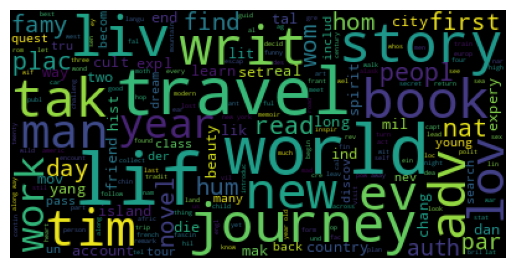

sports


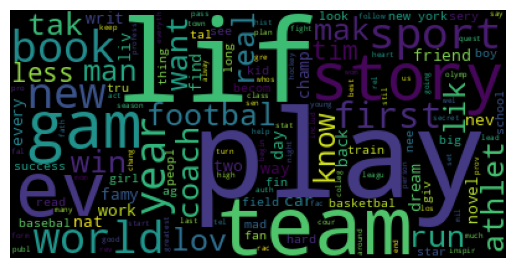

horror


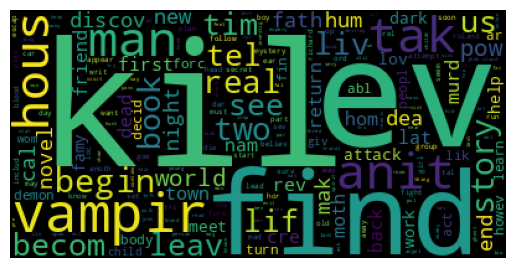

In [3]:
# word clouds on words without stemming - sports, romance, crime & travel have the most characteristic words as most popular
target_genres = ['history', 'thriller', 'romance', 'fantasy', 'crime','science', 'psychology','travel','sports','horror']

for genre in target_genres:
    words = data[data['label'] == genre]['text'].str.cat(sep=' ')
    wc = WordCloud().generate(words)
    print(genre)
    plt.axis('off')
    plt.imshow(wc)
    plt.show()



<Axes: xlabel='genre_filtered', ylabel='title_length'>

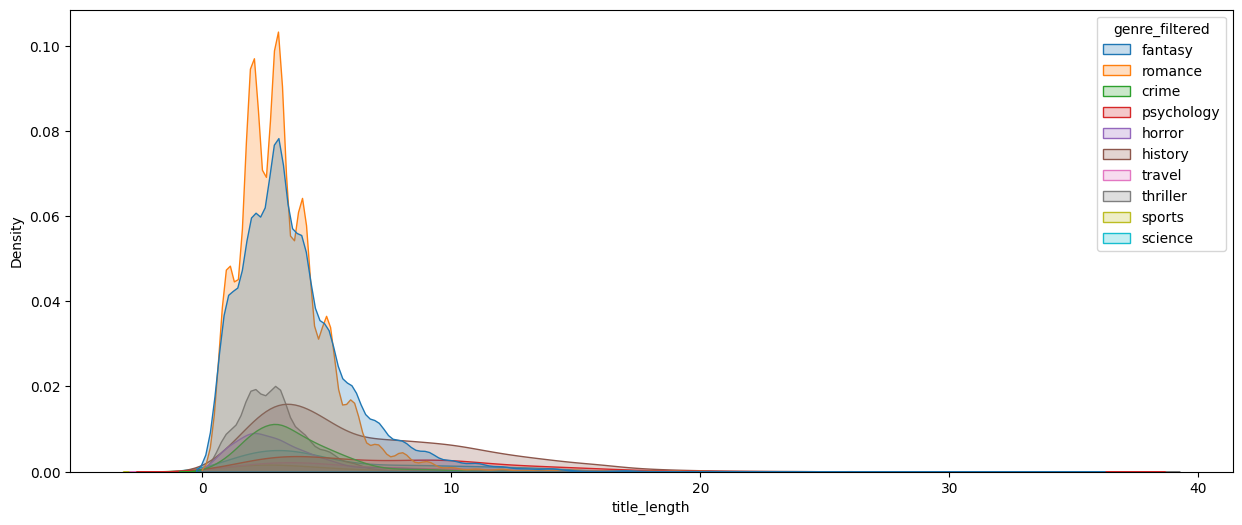

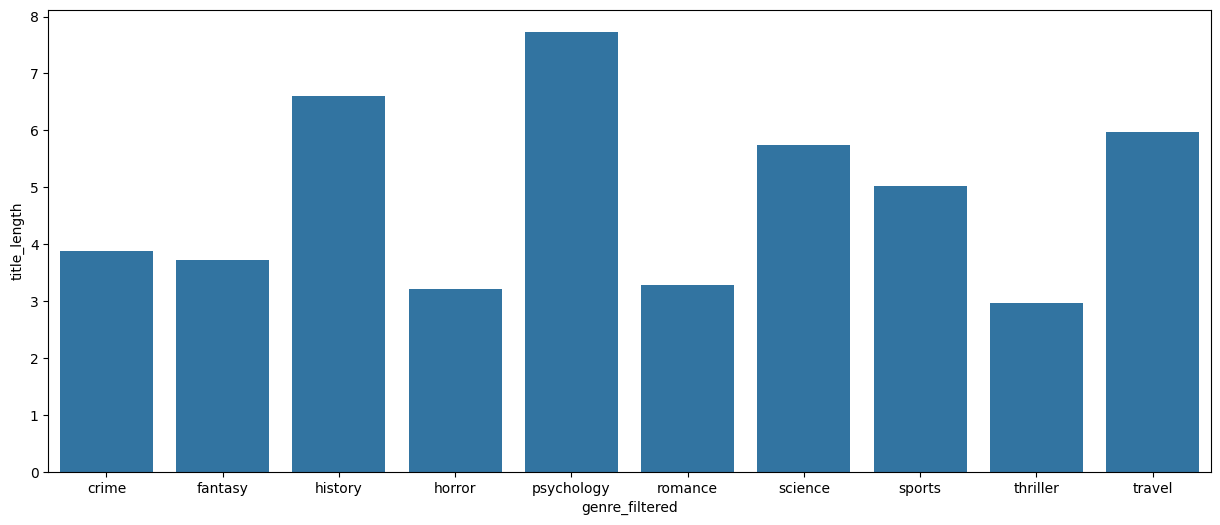

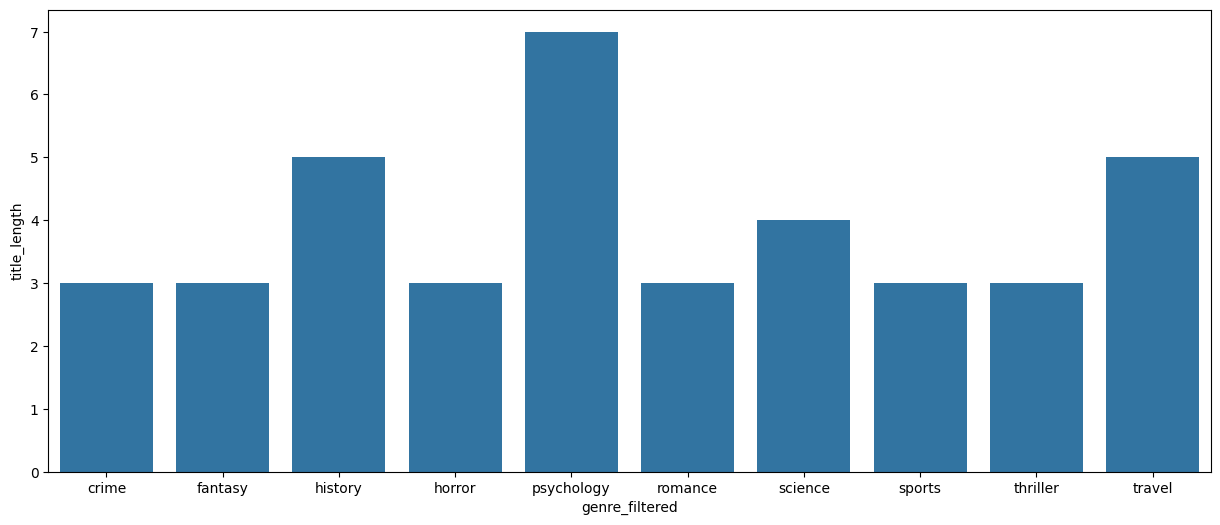

In [25]:
# Distribution of title length across genres & their average and median of title length

original_data = pd.read_csv("cleaned.csv")

original_data['title_length'] = original_data['title'].apply(lambda x: len(x.split()))

original_data.head()

plt.figure(figsize=(15,6))
sns.kdeplot(x=original_data['title_length'], hue = original_data['genre_filtered'], fill=True)

avg_title_length = original_data.groupby('genre_filtered')['title_length'].mean()

plt.figure(figsize=(15,6))
sns.barplot(data=avg_title_length)
median_title_length = original_data.groupby('genre_filtered')['title_length'].median()

plt.figure(figsize=(15,6))
sns.barplot(data=median_title_length)

<Axes: xlabel='genre_filtered', ylabel='desc_length'>

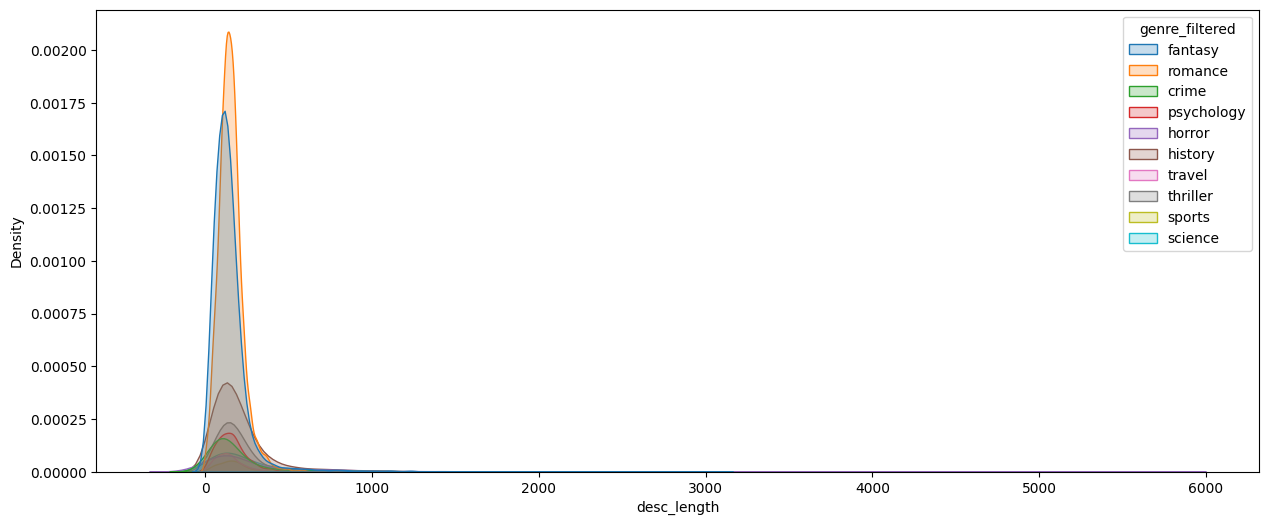

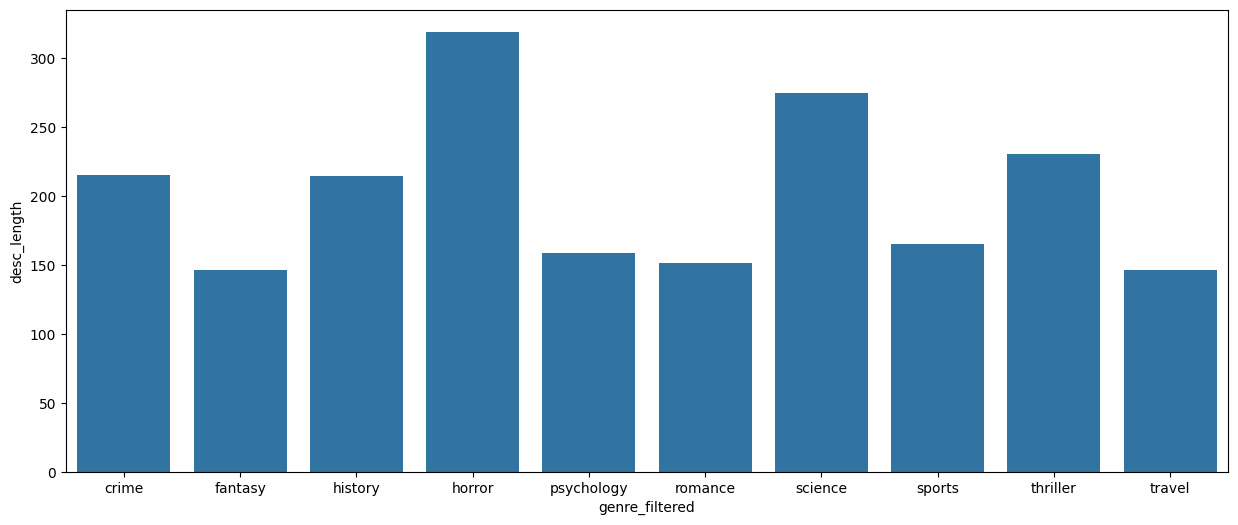

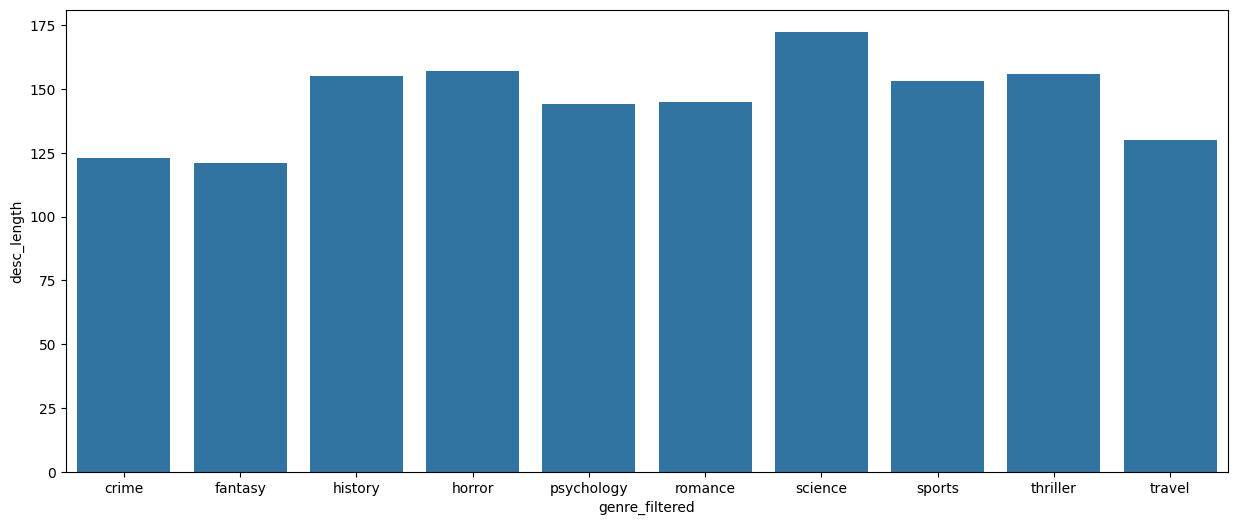

In [24]:
# Distribution of description length across genres & their average and median description length

original_data = pd.read_csv("joined.csv")
original_data['desc_length'] = original_data['description'].apply(lambda x: len(x.split()))

original_data.head()

plt.figure(figsize=(15,6))
sns.kdeplot(x=original_data['desc_length'], hue = original_data['genre_filtered'], fill=True)

avg_title_length = original_data.groupby('genre_filtered')['desc_length'].mean()

plt.figure(figsize=(15,6))
sns.barplot(data=avg_title_length)

median_title_length = original_data.groupby('genre_filtered')['desc_length'].median()

plt.figure(figsize=(15,6))
sns.barplot(data=median_title_length)

In [35]:
mapped_dict = {
    "romance": 0,
    
    "fantasy": 0,
    
    "horror": 0,
    "thriller": 0,
    "crime": 0,
    
    "science": 1,
    "psychology": 1,
    "history": 1,
    "travel": 1
}
class_number = 2

original_data = pd.read_csv("joined.csv")
original_data = original_data.dropna()
original_data['genre'] = original_data['genre_filtered'].map(mapped_dict)
original_data.head()

original_data['predicted_genre'] = original_data['title'].apply(lambda x: 1 if len(x.split())>4 else 0)

good_predictions = np.sum(np.where(original_data['predicted_genre']==original_data['genre'],1,0))
print("Accuracy of simple heuristics and binary classification: ",good_predictions/len(original_data))


Accuracy of simple heuristics and binary classification:  0.7292638063053428
